# Comparative Evaluation of CAM-Based Explainable AI Techniques in Food Image Classification

## Complete experimental notebook

This notebook implements the methodology for comparing **Grad-CAM, Grad-CAM++, Score-CAM and Ablation-CAM** using a single **ResNet50** classifier and the **Food-101** dataset.

The notebook covers:

1. Environment preparation and reproducibility
2. Food-101 download and verification
3. Dataset exploration and visualisation
4. Training, validation and test preprocessing
5. ResNet50 transfer learning and fine-tuning
6. Classification evaluation
7. Selection of correctly classified test images
8. Generation of four CAM explanations
9. Consistent heatmap visualisation
10. Deletion and Insertion faithfulness evaluation
11. Export of figures, tables, checkpoints and environment details



## 1. Install the required packages

PyTorch and TorchVision are normally preinstalled in Google Colab. The following cell installs the CAM implementation package and supporting libraries.

In [ ]:
!pip -q install grad-cam scikit-learn pandas matplotlib opencv-python-headless tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Import libraries and define the experimental configuration

`DEMO_MODE` creates a balanced subset from all 101 classes so that the complete workflow can be tested quickly. Full mode uses the complete official Food-101 training and test partitions.

In [ ]:
from pathlib import Path
import os
import sys
import json
import time
import random
import platform
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM, AblationCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------------------------------------------------------
# Main configuration
# ---------------------------------------------------------
DEMO_MODE = False
SEED = 42
IMAGE_SIZE = 224
VALIDATION_RATIO = 0.10

# Quick balanced demonstration settings
DEMO_TRAIN_IMAGES_PER_CLASS = 20
DEMO_TEST_IMAGES_PER_CLASS = 5
DEMO_EPOCHS = 1
DEMO_CAM_IMAGES = 4

# Full experiment settings
FULL_EPOCHS = 10
FULL_CAM_IMAGES = 25

BATCH_SIZE = 32 if torch.cuda.is_available() else 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 3
PERTURBATION_STEPS = 20

EPOCHS = DEMO_EPOCHS if DEMO_MODE else FULL_EPOCHS
CAM_IMAGE_COUNT = DEMO_CAM_IMAGES if DEMO_MODE else FULL_CAM_IMAGES

RUN_TRAINING = True
FORCE_RETRAIN = False
RUN_CAM_ANALYSIS = False
RUN_FAITHFULNESS_EVALUATION = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Demo mode:", DEMO_MODE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Device: cuda
Demo mode: False
Epochs: 10
Batch size: 32


## 3. Mount Google Drive and create the project folders

The dataset is kept in `/content/data` because accessing thousands of individual image files directly from Drive is slow. Permanent outputs are stored in Google Drive.

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Food101_XAI_Thesis")
    DATA_ROOT = Path("/content/data")
except ImportError:
    PROJECT_ROOT = Path.cwd() / "Food101_XAI_Thesis"
    DATA_ROOT = PROJECT_ROOT / "data"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
HEATMAP_DIR = PROJECT_ROOT / "results" / "heatmaps"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
METRIC_DIR = PROJECT_ROOT / "results" / "metrics"

for folder in [
    PROJECT_ROOT,
    DATA_ROOT,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    HEATMAP_DIR,
    TABLE_DIR,
    METRIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / (
    "resnet50_food101_demo.pt" if DEMO_MODE else "resnet50_food101_full.pt"
)

print("Project root:", PROJECT_ROOT)
print("Dataset location:", DATA_ROOT)
print("Checkpoint:", CHECKPOINT_PATH)

Mounted at /content/drive
Project root: /content/drive/MyDrive/Food101_XAI_Thesis
Dataset location: /content/data
Checkpoint: /content/drive/MyDrive/Food101_XAI_Thesis/checkpoints/resnet50_food101_full.pt


## 4. Reproducibility and runtime information

Fixed seeds are used for Python, NumPy and PyTorch. Software and hardware details are recorded for methodological transparency.

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic settings improve repeatability, although they can reduce speed.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

runtime_info = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "seed": SEED,
    "demo_mode": DEMO_MODE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
}

if torch.cuda.is_available():
    runtime_info["gpu"] = torch.cuda.get_device_name(0)

runtime_path = PROJECT_ROOT / "runtime_information.json"
runtime_path.write_text(json.dumps(runtime_info, indent=2), encoding="utf-8")

runtime_info

{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'cuda_version': '12.8',
 'device': 'cuda',
 'seed': 42,
 'demo_mode': False,
 'image_size': 224,
 'batch_size': 32,
 'epochs': 10,
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'gpu': 'Tesla T4'}

## 5. Define training and evaluation transformations

Training images receive controlled augmentation to improve generalisation. Validation and test images use deterministic transformations so that evaluation remains consistent. ImageNet normalisation is used because the model begins with ImageNet-pretrained weights.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 6. Download and verify Food-101

TorchVision downloads the official Food-101 partitions automatically. The expected complete dataset contains **75,750 training images**, **25,250 test images** and **101 classes**.

In [ ]:
train_dataset_augmented = datasets.Food101(
    root=str(DATA_ROOT),
    split="train",
    download=True,
    transform=train_transform,
)

train_dataset_evaluation = datasets.Food101(
    root=str(DATA_ROOT),
    split="train",
    download=False,
    transform=evaluation_transform,
)

test_dataset_full = datasets.Food101(
    root=str(DATA_ROOT),
    split="test",
    download=True,
    transform=evaluation_transform,
)

print("Complete training partition:", len(train_dataset_augmented))
print("Complete test partition:", len(test_dataset_full))
print("Number of classes:", len(train_dataset_augmented.classes))
print("First ten classes:", train_dataset_augmented.classes[:10])

assert len(train_dataset_augmented) == 75750
assert len(test_dataset_full) == 25250
assert len(train_dataset_augmented.classes) == 101

100%|██████████| 5.00G/5.00G [03:24<00:00, 24.5MB/s]


Complete training partition: 75750
Complete test partition: 25250
Number of classes: 101
First ten classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


## 7. Create balanced demonstration or full experimental subsets

The demonstration mode samples the same number of images from every class. This preserves all 101 categories while reducing runtime. Full mode retains the complete dataset.

In [ ]:
def extract_targets(dataset):
    for attribute in ("_labels", "targets", "labels"):
        if hasattr(dataset, attribute):
            return list(getattr(dataset, attribute))
    raise AttributeError(
        "The dataset label attribute could not be found. "
        "Check the installed TorchVision version."
    )

def balanced_indices(targets, images_per_class=None, seed=42):
    if images_per_class is None:
        return list(range(len(targets)))

    generator = np.random.default_rng(seed)
    class_to_indices = defaultdict(list)

    for index, label in enumerate(targets):
        class_to_indices[int(label)].append(index)

    selected = []
    for class_id in sorted(class_to_indices):
        available = np.array(class_to_indices[class_id])
        generator.shuffle(available)
        selected.extend(available[:images_per_class].tolist())

    return selected

train_targets = extract_targets(train_dataset_augmented)
test_targets = extract_targets(test_dataset_full)

selected_train_indices = balanced_indices(
    train_targets,
    DEMO_TRAIN_IMAGES_PER_CLASS if DEMO_MODE else None,
    SEED,
)

selected_test_indices = balanced_indices(
    test_targets,
    DEMO_TEST_IMAGES_PER_CLASS if DEMO_MODE else None,
    SEED,
)

selected_train_labels = [train_targets[index] for index in selected_train_indices]

train_indices, validation_indices = train_test_split(
    selected_train_indices,
    test_size=VALIDATION_RATIO,
    random_state=SEED,
    stratify=selected_train_labels,
)

train_subset = Subset(train_dataset_augmented, train_indices)
validation_subset = Subset(train_dataset_evaluation, validation_indices)
test_subset = Subset(test_dataset_full, selected_test_indices)

print("Training images used:", len(train_subset))
print("Validation images used:", len(validation_subset))
print("Test images used:", len(test_subset))

Training images used: 68175
Validation images used: 7575
Test images used: 25250


## 8. Build data loaders

The training loader shuffles images. Validation and test loaders preserve their order for consistent evaluation.

In [ ]:
pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

validation_loader = DataLoader(
    validation_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

class_names = train_dataset_augmented.classes

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 2131
Validation batches: 237
Test batches: 790


## 9. Display representative Food-101 images

The following cell reverses ImageNet normalisation and displays sample images with their class labels.

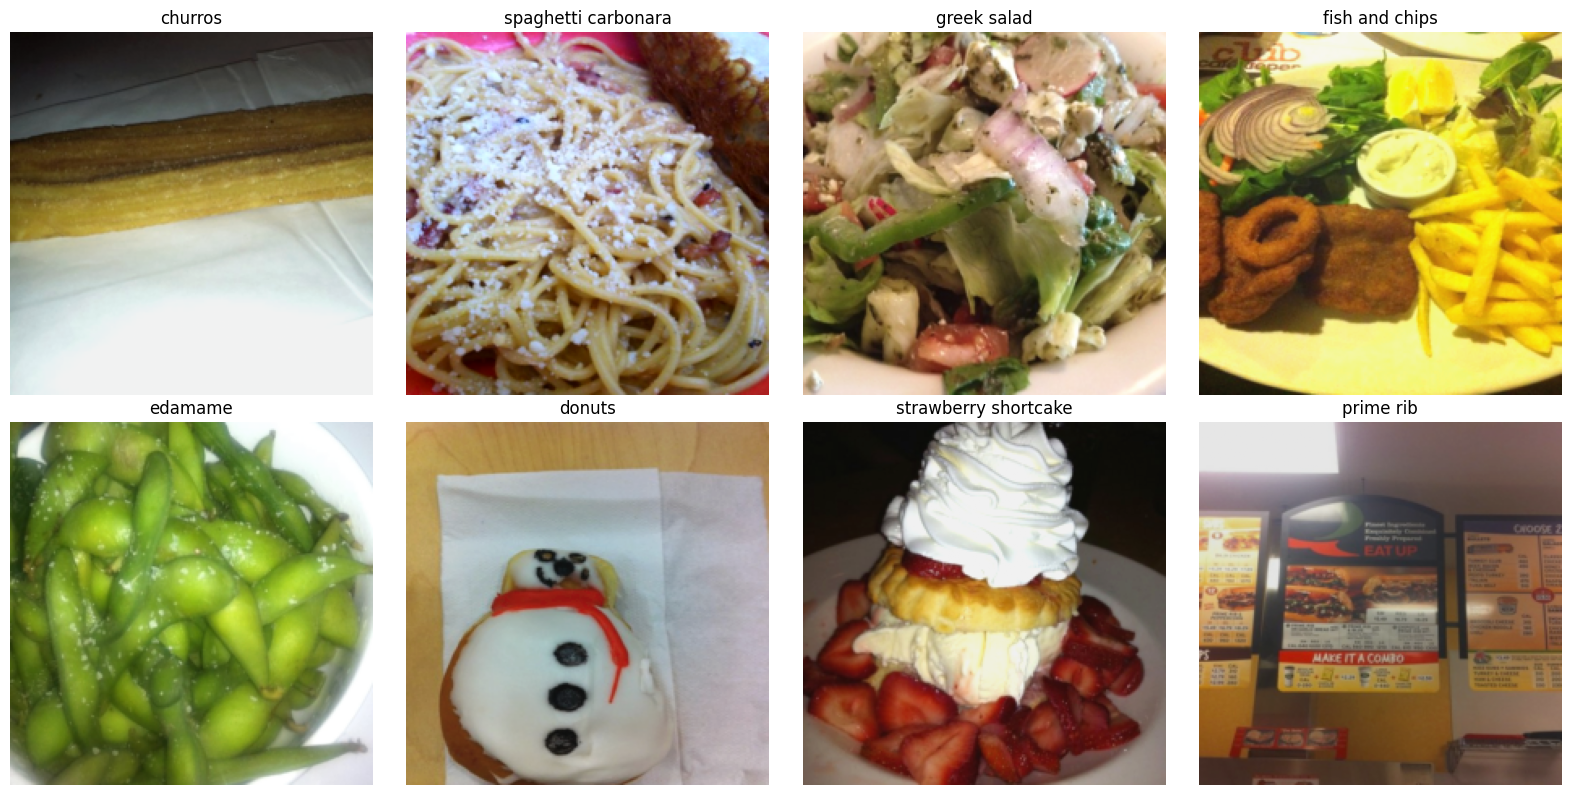

Saved: /content/drive/MyDrive/Food101_XAI_Thesis/results/figures/food101_sample_images.png


In [ ]:
mean_tensor = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_tensor = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def tensor_to_rgb(image_tensor):
    image = image_tensor.detach().cpu() * std_tensor + mean_tensor
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy().astype(np.float32)

images, labels = next(iter(train_loader))

sample_count = min(8, len(images))
plt.figure(figsize=(16, 8))

for position in range(sample_count):
    plt.subplot(2, 4, position + 1)
    plt.imshow(tensor_to_rgb(images[position]))
    plt.title(class_names[int(labels[position])].replace("_", " "))
    plt.axis("off")

plt.tight_layout()
sample_path = FIGURE_DIR / "food101_sample_images.png"
plt.savefig(sample_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", sample_path)

## 10. Configure ResNet50 for 101 food classes

The model uses ImageNet-pretrained weights. Its final classification layer is replaced with a 101-class output layer. The final residual block and the new classification layer are fine-tuned, while earlier layers remain frozen.

In [ ]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, len(class_names))

for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(parameter.numel() for parameter in model.parameters())

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Total parameters: 23,714,981
Trainable parameters: 15,171,685
Linear(in_features=2048, out_features=101, bias=True)


## 11. Define the loss function, optimiser and scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

optimiser = torch.optim.AdamW(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode="min",
    factor=0.5,
    patience=1,
)

## 12. Training and validation functions

The best validation-loss checkpoint is saved. Early stopping prevents unnecessary training when validation performance stops improving.

In [ ]:
def run_epoch(model, loader, training):
    model.train(training)

    running_loss = 0.0
    running_correct = 0
    total_examples = 0

    progress = tqdm(loader, leave=False)

    for inputs, labels in progress:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimiser.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimiser.step()

        predictions = outputs.argmax(dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (predictions == labels).sum().item()
        total_examples += batch_size

        progress.set_postfix(
            loss=f"{running_loss / total_examples:.4f}",
            accuracy=f"{running_correct / total_examples:.4f}",
        )

    epoch_loss = running_loss / total_examples
    epoch_accuracy = running_correct / total_examples
    return epoch_loss, epoch_accuracy


def train_model(model, epochs):
    history = []
    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")

        training_loss, training_accuracy = run_epoch(
            model,
            train_loader,
            training=True,
        )

        validation_loss, validation_accuracy = run_epoch(
            model,
            validation_loader,
            training=False,
        )

        scheduler.step(validation_loss)

        history.append({
            "epoch": epoch,
            "training_loss": training_loss,
            "training_accuracy": training_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "learning_rate": optimiser.param_groups[0]["lr"],
        })

        print(
            f"Training loss: {training_loss:.4f} | "
            f"Training accuracy: {training_accuracy:.4f}"
        )
        print(
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation accuracy: {validation_accuracy:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            epochs_without_improvement = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "history": history,
                "configuration": runtime_info,
            }, CHECKPOINT_PATH)

            print("Saved improved checkpoint.")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping activated.")
            break

    return pd.DataFrame(history)

## 13. Train or load the classifier

For a setup demonstration, one balanced epoch is sufficient to verify the pipeline. Full thesis results should be produced in full mode with the complete dataset and a validated training schedule.

In [ ]:
if CHECKPOINT_PATH.exists() and not FORCE_RETRAIN:
    saved_checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(saved_checkpoint["model_state_dict"])
    training_history = pd.DataFrame(saved_checkpoint.get("history", []))
    print("Loaded existing checkpoint:", CHECKPOINT_PATH)

elif RUN_TRAINING:
    training_history = train_model(model, EPOCHS)

else:
    training_history = pd.DataFrame()
    print("Training was skipped and no checkpoint was loaded.")

if not training_history.empty:
    history_path = TABLE_DIR / "training_history.csv"
    training_history.to_csv(history_path, index=False)
    display(training_history)
    print("Saved:", history_path)

Epoch 1/10


  0%|          | 0/2131 [00:00<?, ?it/s]

  0%|          | 0/237 [00:00<?, ?it/s]

Training loss: 1.8714 | Training accuracy: 0.5509
Validation loss: 1.1038 | Validation accuracy: 0.7060
Saved improved checkpoint.
Epoch 2/10


  0%|          | 0/2131 [00:00<?, ?it/s]

...

  0%|          | 0/237 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cf5ee6999e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cf5ee6999e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Training loss: 0.2461 | Training accuracy: 0.9294
Validation loss: 0.9169 | Validation accuracy: 0.7799
Early stopping activated.


,epoch,training_loss,training_accuracy,validation_loss,validation_accuracy,learning_rate
0,1,1.871373,0.550876,1.103780,0.706007,0.00010
1,2,1.001304,0.734404,0.958529,0.746931,0.00010
2,3,0.760528,0.793150,0.913939,0.762112,0.00010
3,4,0.602671,0.833033,0.892319,0.762244,0.00010
4,5,0.479735,0.865127,0.900944,0.769109,0.00010
5,6,0.381928,0.890136,0.940591,0.767789,0.00005
6,7,0.246055,0.929388,0.916950,0.779934,0.00005


Saved: /content/drive/MyDrive/Food101_XAI_Thesis/results/tables/training_history.csv


## 14. Plot training and validation performance

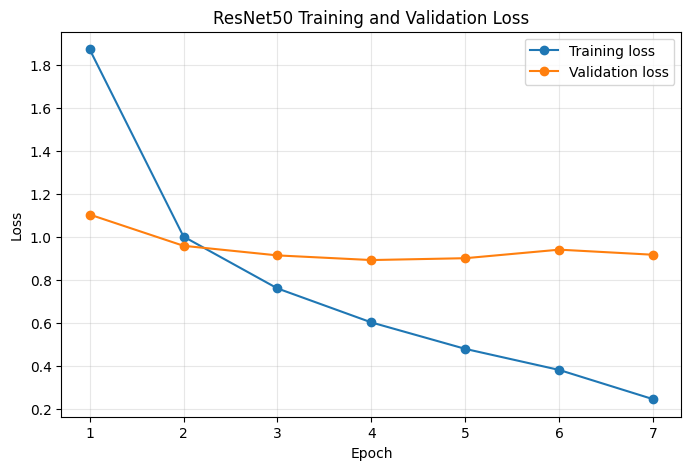

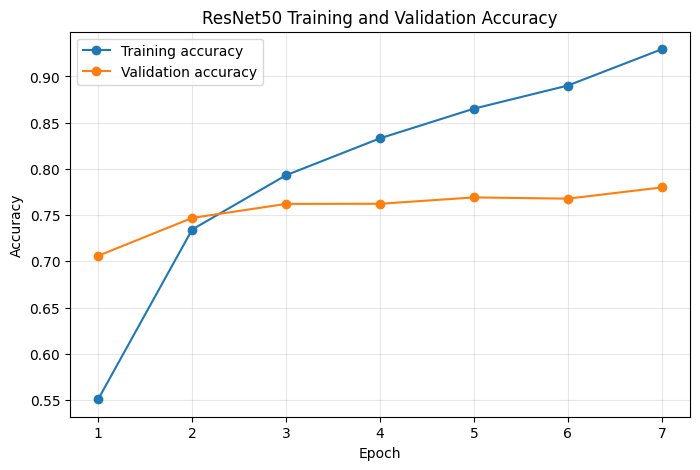

In [ ]:
if not training_history.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(training_history["epoch"], training_history["training_loss"], marker="o", label="Training loss")
    plt.plot(training_history["epoch"], training_history["validation_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet50 Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    loss_figure_path = FIGURE_DIR / "training_validation_loss.png"
    plt.savefig(loss_figure_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(training_history["epoch"], training_history["training_accuracy"], marker="o", label="Training accuracy")
    plt.plot(training_history["epoch"], training_history["validation_accuracy"], marker="o", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet50 Training and Validation Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    accuracy_figure_path = FIGURE_DIR / "training_validation_accuracy.png"
    plt.savefig(accuracy_figure_path, dpi=200, bbox_inches="tight")
    plt.show()

## 15. Evaluate classification performance on the test set

The test evaluation records the true class, predicted class and target-class confidence for every selected test image.

In [ ]:
def evaluate_test_set(model, loader):
    model.eval()

    records = []
    running_loss = 0.0
    running_correct = 0
    total_examples = 0
    global_index = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Testing"):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predictions == labels).sum().item()
            total_examples += batch_size

            for item in range(batch_size):
                true_id = int(labels[item].item())
                predicted_id = int(predictions[item].item())

                records.append({
                    "test_sequence_id": global_index,
                    "true_class_id": true_id,
                    "true_class": class_names[true_id],
                    "predicted_class_id": predicted_id,
                    "predicted_class": class_names[predicted_id],
                    "confidence": float(confidences[item].item()),
                    "correct": bool(true_id == predicted_id),
                })
                global_index += 1

    summary = {
        "test_loss": running_loss / total_examples,
        "test_accuracy": running_correct / total_examples,
        "correct_predictions": running_correct,
        "incorrect_predictions": total_examples - running_correct,
        "evaluated_images": total_examples,
    }

    return pd.DataFrame(records), summary


test_predictions, test_summary = evaluate_test_set(model, test_loader)

prediction_path = TABLE_DIR / "test_predictions.csv"
summary_path = TABLE_DIR / "test_summary.json"

test_predictions.to_csv(prediction_path, index=False)
summary_path.write_text(json.dumps(test_summary, indent=2), encoding="utf-8")

print(json.dumps(test_summary, indent=2))
print("Saved:", prediction_path)
print("Saved:", summary_path)

Testing:   0%|          | 0/790 [00:00<?, ?it/s]

{
  "test_loss": 0.6858262782123604,
  "test_accuracy": 0.8232079207920792,
  "correct_predictions": 20786,
  "incorrect_predictions": 4464,
  "evaluated_images": 25250
}
Saved: /content/drive/MyDrive/Food101_XAI_Thesis/results/tables/test_predictions.csv
Saved: /content/drive/MyDrive/Food101_XAI_Thesis/results/tables/test_summary.json


## 16. Select correctly classified images for explanation

All CAM techniques are applied to the same correctly classified images and their predicted classes. The selection contains varied classes and stops when the configured image count is reached.

In [ ]:
def collect_correctly_classified_images(model, loader, required_count):
    model.eval()
    selected = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs_device = inputs.to(DEVICE)
            outputs = model(inputs_device)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            for item in range(len(labels)):
                true_id = int(labels[item].item())
                predicted_id = int(predictions[item].item())

                if true_id == predicted_id:
                    selected.append({
                        "image_tensor": inputs[item].cpu(),
                        "true_class_id": true_id,
                        "predicted_class_id": predicted_id,
                        "confidence": float(confidences[item].item()),
                    })

                if len(selected) >= required_count:
                    return selected

    return selected


selected_explanation_images = collect_correctly_classified_images(
    model,
    test_loader,
    CAM_IMAGE_COUNT,
)

print("Correctly classified images selected:", len(selected_explanation_images))

if len(selected_explanation_images) == 0:
    raise RuntimeError(
        "No correctly classified images were available. "
        "Train the model for additional epochs or use the full dataset."
    )

Correctly classified images selected: 25


## 17. Generate Grad-CAM, Grad-CAM++, Score-CAM and Ablation-CAM

The final convolutional block of ResNet50 is used as the common target layer. Every method receives the same model, image, target class and visualisation settings.

In [ ]:
target_layers = [model.layer4[-1]]

cam_method_classes = {
    "Grad-CAM": GradCAM,
    "Grad-CAM++": GradCAMPlusPlus,
    "Score-CAM": ScoreCAM,
    "Ablation-CAM": AblationCAM,
}

cam_records = []
cam_maps = {}

if RUN_CAM_ANALYSIS:
    model.eval()

    for method_name, method_class in cam_method_classes.items():
        print("Generating:", method_name)

        with method_class(model=model, target_layers=target_layers) as cam:
            if hasattr(cam, "batch_size"):
                cam.batch_size = 16

            for image_number, item in enumerate(
                tqdm(selected_explanation_images, leave=False)
            ):
                input_tensor = item["image_tensor"].unsqueeze(0).to(DEVICE)
                target_class_id = item["predicted_class_id"]
                targets = [ClassifierOutputTarget(target_class_id)]

                start_time = time.perf_counter()

                grayscale_cam = cam(
                    input_tensor=input_tensor,
                    targets=targets,
                )[0]

                elapsed_seconds = time.perf_counter() - start_time

                key = (image_number, method_name)
                cam_maps[key] = grayscale_cam.astype(np.float32)

                rgb_image = tensor_to_rgb(item["image_tensor"])
                overlay = show_cam_on_image(
                    rgb_image,
                    grayscale_cam,
                    use_rgb=True,
                )

                output_name = (
                    f"image_{image_number:03d}_"
                    f"{method_name.lower().replace('+', 'plus').replace('-', '_')}.png"
                )
                output_path = HEATMAP_DIR / output_name
                cv2.imwrite(str(output_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

                cam_records.append({
                    "image_id": image_number,
                    "method": method_name,
                    "true_class": class_names[item["true_class_id"]],
                    "predicted_class": class_names[target_class_id],
                    "prediction_confidence": item["confidence"],
                    "generation_seconds": elapsed_seconds,
                    "heatmap_file": str(output_path),
                })

    cam_generation_table = pd.DataFrame(cam_records)
    cam_generation_path = TABLE_DIR / "cam_generation_records.csv"
    cam_generation_table.to_csv(cam_generation_path, index=False)

    display(cam_generation_table)
    print("Saved:", cam_generation_path)

## 18. Display the controlled visual comparison

Each row contains the original image followed by the four explanation methods.

In [ ]:
if RUN_CAM_ANALYSIS and cam_maps:
    methods = list(cam_method_classes.keys())
    row_count = len(selected_explanation_images)

    figure, axes = plt.subplots(
        row_count,
        len(methods) + 1,
        figsize=(18, 4 * row_count),
        squeeze=False,
    )

    for image_number, item in enumerate(selected_explanation_images):
        rgb_image = tensor_to_rgb(item["image_tensor"])

        axes[image_number, 0].imshow(rgb_image)
        axes[image_number, 0].set_title(
            "Original\n"
            f"Class: {class_names[item['predicted_class_id']].replace('_', ' ')}\n"
            f"Confidence: {item['confidence']:.3f}"
        )
        axes[image_number, 0].axis("off")

        for method_position, method_name in enumerate(methods, start=1):
            heatmap = cam_maps[(image_number, method_name)]
            overlay = show_cam_on_image(rgb_image, heatmap, use_rgb=True)

            axes[image_number, method_position].imshow(overlay)
            axes[image_number, method_position].set_title(method_name)
            axes[image_number, method_position].axis("off")

    plt.tight_layout()
    comparison_path = FIGURE_DIR / "cam_method_comparison.png"
    plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", comparison_path)

## 19. Define Deletion and Insertion faithfulness evaluation

Deletion progressively replaces the highest-attribution pixels with a blurred baseline. A lower Deletion area under the curve indicates stronger faithfulness.

Insertion begins with the blurred baseline and progressively restores the highest-attribution pixels. A higher Insertion area under the curve indicates stronger faithfulness.

In [ ]:
normalise_tensor = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

def rgb_to_model_tensor(rgb_image):
    tensor = torch.from_numpy(rgb_image.transpose(2, 0, 1)).float()
    tensor = normalise_tensor(tensor)
    return tensor.unsqueeze(0).to(DEVICE)

def target_confidence(model, rgb_image, target_class_id):
    input_tensor = rgb_to_model_tensor(rgb_image)

    with torch.no_grad():
        probabilities = torch.softmax(model(input_tensor), dim=1)

    return float(probabilities[0, target_class_id].item())

def perturbation_curves(
    model,
    image_tensor,
    heatmap,
    target_class_id,
    steps=20,
):
    original = tensor_to_rgb(image_tensor)
    height, width, _ = original.shape

    # A blurred image is used as the common perturbation baseline.
    baseline = cv2.GaussianBlur(original, (51, 51), sigmaX=0)

    ranking = np.argsort(heatmap.reshape(-1))[::-1]
    chunk_size = int(np.ceil(len(ranking) / steps))

    deletion_image = original.copy()
    insertion_image = baseline.copy()

    deletion_scores = [target_confidence(model, deletion_image, target_class_id)]
    insertion_scores = [target_confidence(model, insertion_image, target_class_id)]

    for step in range(steps):
        selected_pixels = ranking[
            step * chunk_size : min((step + 1) * chunk_size, len(ranking))
        ]

        rows = selected_pixels // width
        columns = selected_pixels % width

        deletion_image[rows, columns, :] = baseline[rows, columns, :]
        insertion_image[rows, columns, :] = original[rows, columns, :]

        deletion_scores.append(
            target_confidence(model, deletion_image, target_class_id)
        )
        insertion_scores.append(
            target_confidence(model, insertion_image, target_class_id)
        )

    x_axis = np.linspace(0, 1, len(deletion_scores))

    # np.trapezoid is preferred when available; np.trapz is retained as fallback.
    area_function = getattr(np, "trapezoid", np.trapz)

    deletion_auc = float(area_function(deletion_scores, x_axis))
    insertion_auc = float(area_function(insertion_scores, x_axis))

    return {
        "x_axis": x_axis,
        "deletion_scores": deletion_scores,
        "insertion_scores": insertion_scores,
        "deletion_auc": deletion_auc,
        "insertion_auc": insertion_auc,
    }

## 20. Calculate Deletion and Insertion Scores for every selected image and method

In [ ]:
faithfulness_records = []
faithfulness_curves = {}

if RUN_FAITHFULNESS_EVALUATION and cam_maps:
    model.eval()

    for image_number, item in enumerate(selected_explanation_images):
        for method_name in cam_method_classes:
            print(f"Faithfulness: image {image_number}, {method_name}")

            result = perturbation_curves(
                model=model,
                image_tensor=item["image_tensor"],
                heatmap=cam_maps[(image_number, method_name)],
                target_class_id=item["predicted_class_id"],
                steps=PERTURBATION_STEPS,
            )

            faithfulness_curves[(image_number, method_name)] = result

            faithfulness_records.append({
                "image_id": image_number,
                "method": method_name,
                "true_class": class_names[item["true_class_id"]],
                "predicted_class": class_names[item["predicted_class_id"]],
                "prediction_confidence": item["confidence"],
                "deletion_auc": result["deletion_auc"],
                "insertion_auc": result["insertion_auc"],
            })

    faithfulness_table = pd.DataFrame(faithfulness_records)
    faithfulness_path = METRIC_DIR / "deletion_insertion_scores.csv"
    faithfulness_table.to_csv(faithfulness_path, index=False)

    display(faithfulness_table)
    print("Saved:", faithfulness_path)

## 21. Aggregate and compare the four explanation methods

The table reports average performance and variability across the common image set. Better faithfulness is indicated by a lower mean Deletion AUC and a higher mean Insertion AUC.

In [ ]:
if RUN_FAITHFULNESS_EVALUATION and faithfulness_records:
    method_summary = (
        faithfulness_table
        .groupby("method")
        .agg(
            mean_deletion_auc=("deletion_auc", "mean"),
            standard_deviation_deletion=("deletion_auc", "std"),
            mean_insertion_auc=("insertion_auc", "mean"),
            standard_deviation_insertion=("insertion_auc", "std"),
            evaluated_images=("image_id", "count"),
        )
        .reset_index()
        .sort_values(
            ["mean_deletion_auc", "mean_insertion_auc"],
            ascending=[True, False],
        )
    )

    summary_output_path = METRIC_DIR / "cam_method_faithfulness_summary.csv"
    method_summary.to_csv(summary_output_path, index=False)

    display(method_summary)
    print("Saved:", summary_output_path)

    plt.figure(figsize=(9, 5))
    plt.bar(method_summary["method"], method_summary["mean_deletion_auc"])
    plt.ylabel("Mean Deletion AUC")
    plt.title("Deletion Faithfulness Comparison: Lower Is Better")
    plt.xticks(rotation=20)
    plt.tight_layout()
    deletion_chart_path = FIGURE_DIR / "mean_deletion_auc_by_method.png"
    plt.savefig(deletion_chart_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.bar(method_summary["method"], method_summary["mean_insertion_auc"])
    plt.ylabel("Mean Insertion AUC")
    plt.title("Insertion Faithfulness Comparison: Higher Is Better")
    plt.xticks(rotation=20)
    plt.tight_layout()
    insertion_chart_path = FIGURE_DIR / "mean_insertion_auc_by_method.png"
    plt.savefig(insertion_chart_path, dpi=200, bbox_inches="tight")
    plt.show()

## 22. Plot representative Deletion and Insertion curves

In [ ]:
if RUN_FAITHFULNESS_EVALUATION and faithfulness_curves:
    example_image_id = 0

    plt.figure(figsize=(10, 6))
    for method_name in cam_method_classes:
        result = faithfulness_curves[(example_image_id, method_name)]
        plt.plot(
            result["x_axis"],
            result["deletion_scores"],
            marker="o",
            markersize=3,
            label=method_name,
        )

    plt.xlabel("Proportion of attributed pixels deleted")
    plt.ylabel("Target-class confidence")
    plt.title("Deletion Curves for One Correctly Classified Food Image")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    deletion_curve_path = FIGURE_DIR / "representative_deletion_curves.png"
    plt.savefig(deletion_curve_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    for method_name in cam_method_classes:
        result = faithfulness_curves[(example_image_id, method_name)]
        plt.plot(
            result["x_axis"],
            result["insertion_scores"],
            marker="o",
            markersize=3,
            label=method_name,
        )

    plt.xlabel("Proportion of attributed pixels inserted")
    plt.ylabel("Target-class confidence")
    plt.title("Insertion Curves for One Correctly Classified Food Image")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    insertion_curve_path = FIGURE_DIR / "representative_insertion_curves.png"
    plt.savefig(insertion_curve_path, dpi=200, bbox_inches="tight")
    plt.show()

## 23. Create a structured qualitative assessment sheet

The visual assessment should be completed after inspecting the controlled heatmap comparison. Scores use a five-point scale.

- **Food-region concentration:** 1 = very weak, 5 = very strong
- **Background attention:** 1 = very low, 5 = very high
- **Visual clarity:** 1 = very unclear, 5 = very clear
- **Coverage of relevant components:** 1 = very limited, 5 = comprehensive

In [ ]:
qualitative_rows = []

for image_number, item in enumerate(selected_explanation_images):
    for method_name in cam_method_classes:
        qualitative_rows.append({
            "image_id": image_number,
            "method": method_name,
            "true_class": class_names[item["true_class_id"]],
            "predicted_class": class_names[item["predicted_class_id"]],
            "food_region_concentration_1_to_5": "",
            "background_attention_1_to_5": "",
            "visual_clarity_1_to_5": "",
            "coverage_of_relevant_components_1_to_5": "",
            "plate_or_utensil_attention": "",
            "notes": "",
        })

qualitative_template = pd.DataFrame(qualitative_rows)
qualitative_path = TABLE_DIR / "qualitative_heatmap_assessment_template.csv"
qualitative_template.to_csv(qualitative_path, index=False)

display(qualitative_template.head(12))
print("Saved:", qualitative_path)

,image_id,method,true_class,predicted_class,food_region_concentration_1_to_5,background_attention_1_to_5,visual_clarity_1_to_5,coverage_of_relevant_components_1_to_5,plate_or_utensil_attention,notes
0,0,Grad-CAM,churros,churros,,,,,,
1,0,Grad-CAM++,churros,churros,,,,,,
2,0,Score-CAM,churros,churros,,,,,,
3,0,Ablation-CAM,churros,churros,,,,,,
4,1,Grad-CAM,churros,churros,,,,,,
5,1,Grad-CAM++,churros,churros,,,,,,
6,1,Score-CAM,churros,churros,,,,,,
7,1,Ablation-CAM,churros,churros,,,,,,
8,2,Grad-CAM,churros,churros,,,,,,
9,2,Grad-CAM++,churros,churros,,,,,,


Saved: /content/drive/MyDrive/Food101_XAI_Thesis/results/tables/qualitative_heatmap_assessment_template.csv


## 24. Save the final experimental configuration

This file records the central methodological settings used for the classification and explanation experiment.

In [ ]:
experiment_configuration = {
    "research_dataset": "Food-101",
    "classifier": "ResNet50",
    "pretrained_weights": "ImageNet default weights",
    "number_of_classes": len(class_names),
    "training_images_used": len(train_subset),
    "validation_images_used": len(validation_subset),
    "test_images_used": len(test_subset),
    "image_size": IMAGE_SIZE,
    "training_augmentation": [
        "RandomResizedCrop",
        "RandomHorizontalFlip",
        "ColorJitter",
        "ImageNet normalisation",
    ],
    "evaluation_preprocessing": [
        "Resize to 256",
        "CenterCrop to 224",
        "ImageNet normalisation",
    ],
    "fine_tuned_components": ["layer4", "fully connected layer"],
    "loss_function": "CrossEntropyLoss",
    "optimiser": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "epochs": EPOCHS,
    "target_cam_layer": "ResNet50 layer4[-1]",
    "cam_methods": list(cam_method_classes.keys()),
    "explanation_images": len(selected_explanation_images),
    "faithfulness_metrics": ["Deletion AUC", "Insertion AUC"],
    "perturbation_baseline": "Gaussian-blurred version of each image",
    "perturbation_steps": PERTURBATION_STEPS,
    "random_seed": SEED,
    "demo_mode": DEMO_MODE,
}

configuration_path = PROJECT_ROOT / "experiment_configuration.json"
configuration_path.write_text(
    json.dumps(experiment_configuration, indent=2),
    encoding="utf-8",
)

print(json.dumps(experiment_configuration, indent=2))
print("Saved:", configuration_path)

{
  "research_dataset": "Food-101",
  "classifier": "ResNet50",
  "pretrained_weights": "ImageNet default weights",
  "number_of_classes": 101,
  "training_images_used": 68175,
  "validation_images_used": 7575,
  "test_images_used": 25250,
  "image_size": 224,
  "training_augmentation": [
    "RandomResizedCrop",
    "RandomHorizontalFlip",
    "ColorJitter",
    "ImageNet normalisation"
  ],
  "evaluation_preprocessing": [
    "Resize to 256",
    "CenterCrop to 224",
    "ImageNet normalisation"
  ],
  "fine_tuned_components": [
    "layer4",
    "fully connected layer"
  ],
  "loss_function": "CrossEntropyLoss",
  "optimiser": "AdamW",
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "epochs": 10,
  "target_cam_layer": "ResNet50 layer4[-1]",
  "cam_methods": [
    "Grad-CAM",
    "Grad-CAM++",
    "Score-CAM",
    "Ablation-CAM"
  ],
  "explanation_images": 25,
  "faithfulness_metrics": [
    "Deletion AUC",
    "Insertion AUC"
  ],
  "perturbation_baseline": "Gaussian-blurred